## 1. Define Stats Recipe

In [1]:
from src.stats.client import FinancialStatistics

from nvflare.recipe.fedstats import FedStatsRecipe
from nvflare.recipe.prod_env import ProdEnv

df_stats_generator = FinancialStatistics(data_path="/workspace/dataset/paysim1/PS_20174392719_1491204439457_log.csv")  # assumes each client uses the same data path

statistic_configs = {
    "count": {},
    "mean": {},
    "sum": {},
    "stddev": {},
    "histogram": {"*": {"bins": 128, "range": [0, 10e3]}, "amount": {"bins": 128, "range": [0, 500e3]}},
    "quantile": {"*": [0.1, 0.5, 0.9], "isFraud": [0.01, 0.2, 0.5]},
}

recipe = FedStatsRecipe(
    name="fedstats",
    sites=["site5"],
    statistic_configs=statistic_configs,
    stats_generator=df_stats_generator,
    stats_output_path="statistics/financial_stats.json"
)

recipe.export("transfer")

## 2. Run in Production Environment

In [2]:
env = ProdEnv(startup_kit_dir="/scratch/hroth/Code/JPM/admin")
run = recipe.execute(env=env)


Connecting to FLARE ...
Submitted job 'fed_job' with ID: 15f3bdca-65a0-4fd1-92ee-3b7112b01d6f


### Get Status

In [3]:
print("Job Status is:", run.get_status())

Connecting to FLARE ...
Job Status is: RUNNING


### Get Results

In [4]:
result_path = run.get_result()
print("Result can be found in:", result_path)

Connecting to FLARE ...
job monitor done: rc=<MonitorReturnCode.JOB_FINISHED: 0>
Result can be found in: /scratch/hroth/Code/JPM/admin/transfer/15f3bdca-65a0-4fd1-92ee-3b7112b01d6f


## 3. Show stats

In [5]:
stats_file = result_path + '/workspace/statistics/financial_stats.json'
!head -c 200 {stats_file}

{"amount": {"count": {"site5": {"train": 5090096, "test": 1272524}, "Global": {"train": 5090096, "test": 1272524}}, "mean": {"site5": {"train": 179832.6166, "test": 179979.0514}, "Global": {"train": 1

In [6]:
import json

from nvflare.app_opt.statistics.visualization.statistics_visualization import Visualization

with open(stats_file, 'r') as f:
    data = json.load(f)

### Overall stats

In [7]:
vis = Visualization()
vis.show_stats(data = data)


amount



,count,mean,sum,quantile,stddev,histogram
site5-train,5090096,179832.6166,9.153653e+11,{},600330.8646,"[[0.0, 3906.25, 444073], [3906.25, 7812.5, 396..."
site5-test,1272524,179979.0514,2.290277e+11,{},617766.5499,"[[0.0, 3906.25, 110794], [3906.25, 7812.5, 989..."
Global-train,5090096,179832.6166,9.153653e+11,NaN,600330.8646,"[[0.0, 3906.25, 444073], [3906.25, 7812.5, 396..."
Global-test,1272524,179979.0514,2.290277e+11,NaN,617766.5499,"[[0.0, 3906.25, 110794], [3906.25, 7812.5, 989..."



oldbalanceOrg



,count,mean,sum,quantile,stddev,histogram
site5-train,5090096,833597.4524,4.243091e+12,{},2.888401e+06,"[[0.0, 78.125, 1703155], [78.125, 156.25, 4504..."
site5-test,1272524,835025.7109,1.062590e+12,{},2.887609e+06,"[[0.0, 78.125, 425480], [78.125, 156.25, 11131..."
Global-train,5090096,833597.4524,4.243091e+12,NaN,2.888401e+06,"[[0.0, 78.125, 1703155], [78.125, 156.25, 4504..."
Global-test,1272524,835025.7109,1.062590e+12,NaN,2.887609e+06,"[[0.0, 78.125, 425480], [78.125, 156.25, 11131..."



newbalanceOrig



...

,count,mean,sum,quantile,stddev,histogram
site5-train,5090096,1.100422e+06,5.601255e+12,{},3.397732e+06,"[[0.0, 78.125, 2164209], [78.125, 156.25, 853]..."
site5-test,1272524,1.101819e+06,1.402091e+12,{},3.404967e+06,"[[0.0, 78.125, 540872], [78.125, 156.25, 224],..."
Global-train,5090096,1.100422e+06,5.601255e+12,NaN,3.397732e+06,"[[0.0, 78.125, 2164209], [78.125, 156.25, 853]..."
Global-test,1272524,1.101819e+06,1.402091e+12,NaN,3.404967e+06,"[[0.0, 78.125, 540872], [78.125, 156.25, 224],..."



newbalanceDest



,count,mean,sum,quantile,stddev,histogram
site5-train,5090096,1.224630e+06,6.233486e+12,{},3.667626e+06,"[[0.0, 78.125, 1951882], [78.125, 156.25, 201]..."
site5-test,1272524,1.226461e+06,1.560701e+12,{},3.700027e+06,"[[0.0, 78.125, 487816], [78.125, 156.25, 50], ..."
Global-train,5090096,1.224630e+06,6.233486e+12,NaN,3.667626e+06,"[[0.0, 78.125, 1951882], [78.125, 156.25, 201]..."
Global-test,1272524,1.226461e+06,1.560701e+12,NaN,3.700027e+06,"[[0.0, 78.125, 487816], [78.125, 156.25, 50], ..."



isFraud



,count,mean,sum,quantile,stddev,histogram
site5-train,5090096,0.0013,6592,{},0.0360,"[[0.0, 78.125, 5090096], [78.125, 156.25, 0], ..."
site5-test,1272524,0.0013,1621,{},0.0357,"[[0.0, 78.125, 1272524], [78.125, 156.25, 0], ..."
Global-train,5090096,0.0013,6592,NaN,0.0361,"[[0.0, 78.125, 5090096], [78.125, 156.25, 0], ..."
Global-test,1272524,0.0013,1621,NaN,0.0361,"[[0.0, 78.125, 1272524], [78.125, 156.25, 0], ..."


## Histogram Visualization

(see [here](https://github.com/NVIDIA/NVFlare/blob/main/examples/advanced/federated-statistics/df_stats/demo/visualization.ipynb) for more display options)

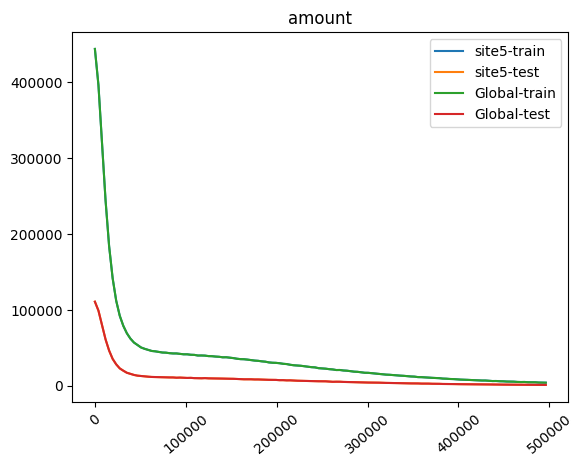

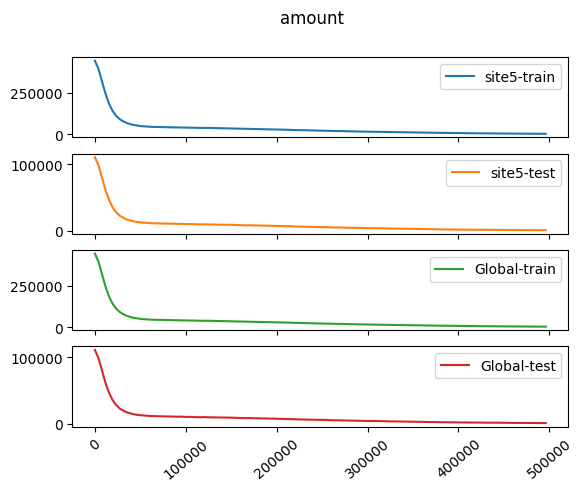

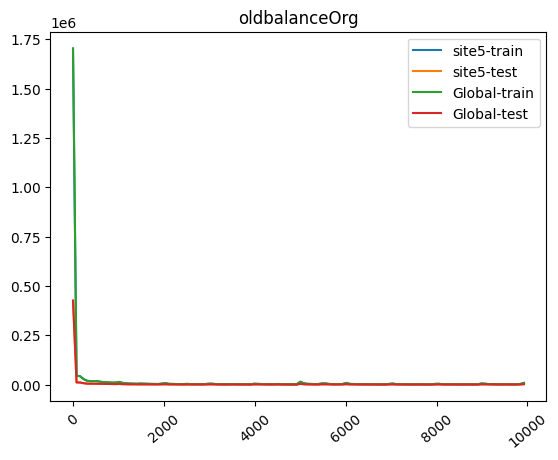

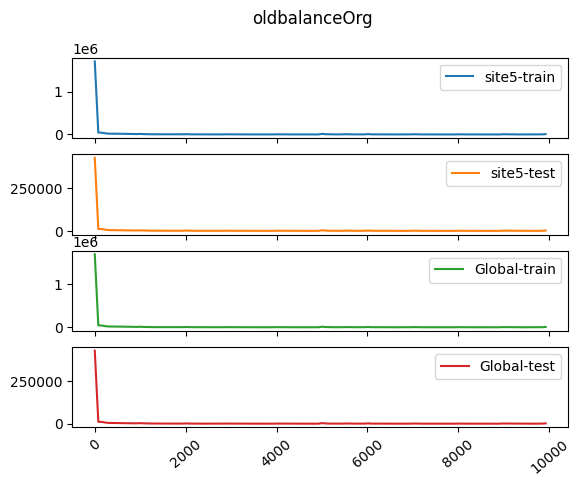

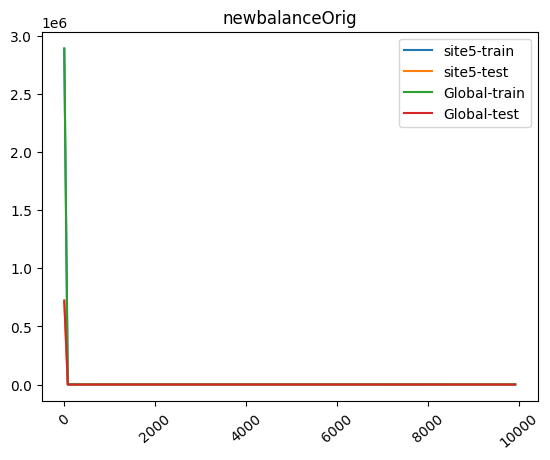

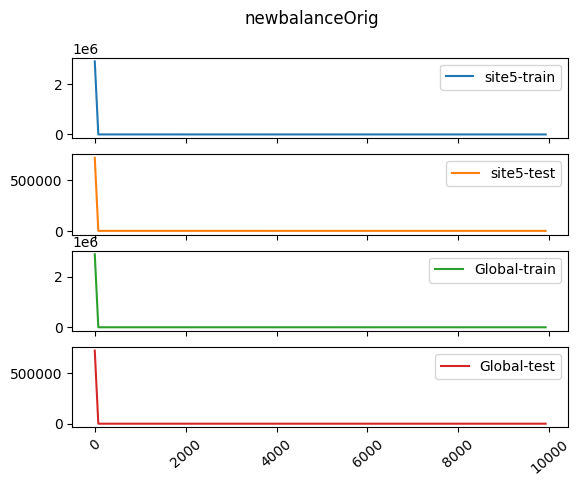

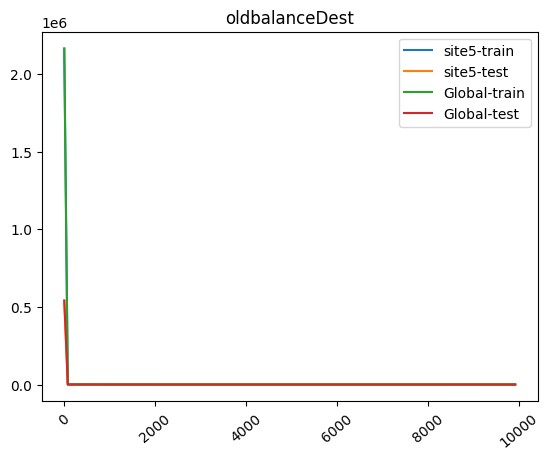

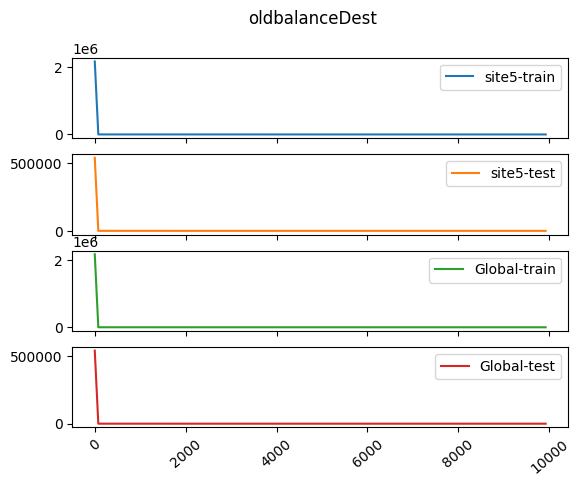

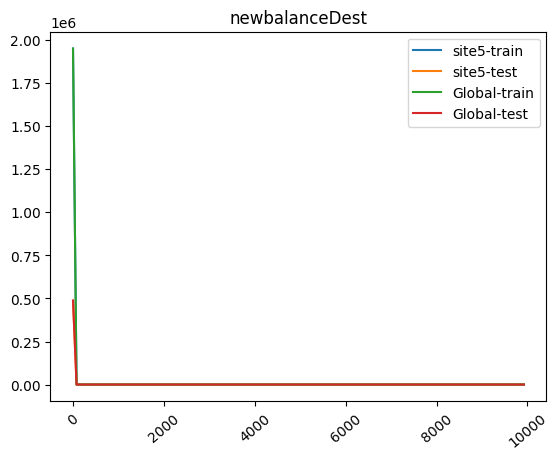

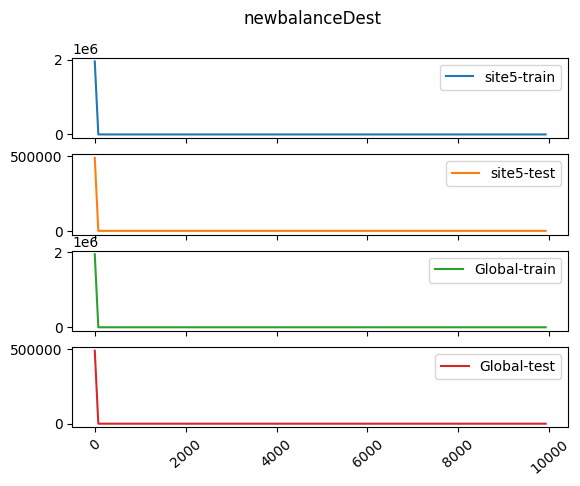

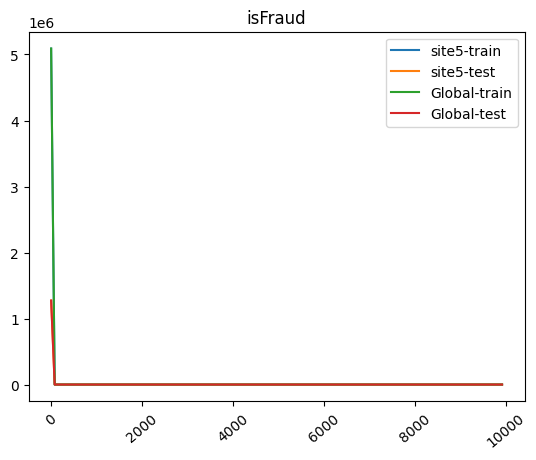

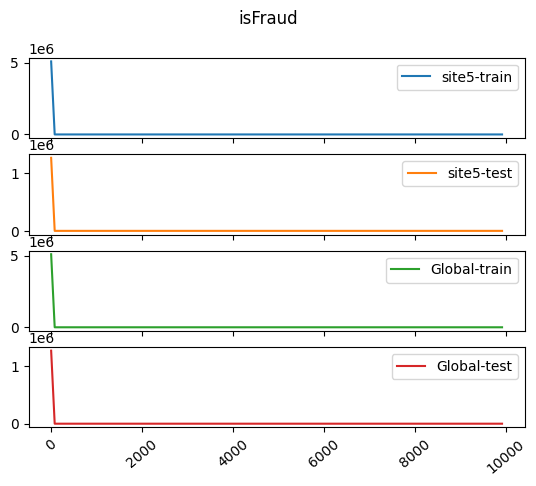

In [8]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:100%  depth:100% !important; }</style>"))

vis.show_histograms(data = data) # display_format = "percent"